In [1]:
%pip install matplotlib


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
from pyspark import SparkContext
import findspark
import numpy as np
import os
from time import perf_counter
import matplotlib.pyplot as plt
sc = SparkContext("local[*]", "Ejercicio3")

ValueError: Cannot run multiple SparkContexts at once; existing SparkContext(app=Prueba_0, master=local[8]) created by __init__ at /tmp/ipykernel_199/1529376768.py:5 

# EJERCICIO 3

## CODIGO DEL EJERCICIO 1

In [2]:
def readFile (filename): 
    '''Arguments: 
    filename – name of the spam dataset file 
    12 columns: 11 features/dimensions (X) + 1 column with labels (Y) 
    Y -- Train labels (0 if normal traffic, 1 if botnet)  
    m rows: number of examples (m) 
    Returns: 
    An RDD containing the data of filename. Each example (row) of the file 
    corresponds to one RDD record. Each record of the RDD is a tuple (X,y).  
    “X” is an array containing the 11 features (float number) of an example  
    “y” is the 12th column of an example (integer 0/1) '''
    result = sc.textFile(filename)
    map_result = result.map(lambda row: [float(x) for x in row.split(",")])
    rdd_xy = map_result.map(lambda row: (row[:11],row[11]))
    return rdd_xy

In [4]:
# Prueba
data=readFile("./botnet_tot_syn_l.csv")
data.take(2)

[([9.012784269851089,
   1672.9999766891833,
   21.99998846107087,
   0.9999997452701503,
   61.99988768910407,
   69.99980788311223,
   13.000000232993186,
   2.9999999785934133,
   199.00000192395984,
   2468369573.0148935,
   2468372549.224571],
  1.0),
 ([3599.9990884099398,
   48206.57583515873,
   13362.999847123127,
   1.0000019205086303,
   262.99924185046257,
   82.99988759205826,
   13.999945225127506,
   5.000000032871429,
   216.99999612378573,
   1539044199.5873349,
   2468368394.7593513],
  0.0)]

In [5]:
rows_rdd = data.map(lambda line: line[0])
print(rows_rdd.take(1))
print()
cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
print(cols_rdd.take(5))
print()
group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
print(group_rdd.take(1))
print()
mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
print(mean_rdd.collect())
print()
broadcast_var = sc.broadcast(dict(mean_rdd.collect()))

[[9.012784269851089, 1672.9999766891833, 21.99998846107087, 0.9999997452701503, 61.99988768910407, 69.99980788311223, 13.000000232993186, 2.9999999785934133, 199.00000192395984, 2468369573.0148935, 2468372549.224571]]

[(0, (9.012784269851089, 81.23028029487523, 1)), (1, (1672.9999766891833, 2798928.9220020077, 1)), (2, (21.99998846107087, 483.9994922872514, 1)), (3, (0.9999997452701503, 0.9999994905403655, 1)), (4, (61.99988768910407, 3843.9860734615186, 1))]



[Stage 3:====================================================>      (8 + 1) / 9]

[(0, (1281538272.9462628, 4221233394864.5664, 1000000))]

[(0, (1281.5382729462629, np.float64(1605.8932249182935))), (9, (2130603014.3773189, np.float64(713843442.8521906))), (1, (21282.767194882716, np.float64(24117.4750428853))), (10, (2261491802.491662, np.float64(1301531949.9426913))), (2, (6948.057181364392, np.float64(16394.945350993465))), (3, (62631.1960911871, np.float64(134264.21801130084))), (4, (122198594.92861378, np.float64(233920713.61972862))), (5, (15722236.101999493, np.float64(44123779.49184376))), (6, (9.107313932259263, np.float64(5.281725807207843))), (7, (1.8897547959110095, np.float64(2.10134561021457))), (8, (124.27015928413205, np.float64(90.3431222388102)))]



In [6]:
import numpy as np

N = data.count()
sum_x, sum_sq_x = data.map(
    lambda line: (np.array(line[0]), np.array(line[0])**2)
).reduce(
    lambda a, b: (a[0] + b[0], a[1] + b[1])
)

mean = sum_x / N
variance = (sum_sq_x / N) - (mean**2)
std_dev = np.sqrt(variance)

In [3]:
def normalize (RDD_Xy): 
    '''Arguments: 
    RDD_Xy is an RDD containing data examples. Each record of the RDD is a tuple 
    (X,y). 
    “X” is an array containing the 11 features (float number) of an example 
    “y” is the label of the example (integer 0/1)  
    Returns: 
    An RDD rescaled to N(0,1) in each column (mean=0, standard deviation=1) '''
    def map_normalize (RDD_Xy): 
        result = []
        x, y = RDD_Xy
        var = broadcast_var.value
        for i, x in enumerate(x):
             mean_aux, std_aux = var[i]
             if(std_aux!=0):
                 result.append((x - mean_aux)/std_aux)
             else:
                 result.append(0.0)
        return result, y
        
    rdd_norm = RDD_Xy.map(map_normalize)
    return rdd_norm

In [12]:
import numpy as np
def normalize_numpy(data): 
    N = data.count()
    sum_x, sum_sq_x = data.map(
        lambda line: (np.array(line[0]), np.array(line[0])**2)
    ).reduce(
        lambda a, b: (a[0] + b[0], a[1] + b[1])
    )
    mean = sum_x / N
    variance = (sum_sq_x / N) - (mean**2)
    std_dev = np.sqrt(variance)
    return data.map(lambda x: ((np.array(x[0]) - mean) / std_dev, x[1]))

In [9]:
rdd_norm = normalize(data)
print(rdd_norm.take(2))

[([np.float64(-0.792409774778866), np.float64(-0.8130937083307339), np.float64(-0.4224507642218906), np.float64(-0.4664697491193844), np.float64(-0.5223929554497563), np.float64(-0.35631956924945285), np.float64(0.7370102960327225), np.float64(0.5283496333423401), np.float64(0.8271779941619601), np.float64(0.4731661571170488), np.float64(0.15895172357621995)], 1.0), ([np.float64(1.443720404002351), np.float64(1.1163610034798641), np.float64(0.39127563577819524), np.float64(-0.4664697491031832), np.float64(-0.5223920961870128), np.float64(-0.35631927462193325), np.float64(0.9263319360863808), np.float64(1.480120748267978), np.float64(1.0264183320400917), np.float64(-0.8286954523619166), np.float64(0.15894853159524694)], 0.0)]


In [10]:
rdd_norm = normalize_numpy(data)
print(rdd_norm.take(2))

[(array([-0.79240977, -0.81309371, -0.42245076, -0.46646975, -0.52239296,
       -0.35631957,  0.7370103 ,  0.52834963,  0.82717799,  0.47316616,
        0.15895172]), 1.0), (array([ 1.4437204 ,  1.116361  ,  0.39127564, -0.46646975, -0.5223921 ,
       -0.35631927,  0.92633194,  1.48012075,  1.02641833, -0.82869545,
        0.15894853]), 0.0)]


In [11]:
# QUITAR: COMPROBACION SI DA 1 PARA CADA INDICE LA SUMA
import math
# comprobar que cada columna queda ~ media 0 y std 1
x_norm = rdd_norm.map(lambda xy: xy[0])

check = (
    x_norm
    .flatMap(lambda row: [(i, (v, v*v, 1)) for i, v in enumerate(row)])
    .reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1], a[2]+b[2]))
    .mapValues(lambda t: (
        t[0]/t[2],  # mean
        math.sqrt(max((t[1]/t[2]) - (t[0]/t[2])**2, 0.0))  # std
    ))
    .collect()
)

print(sorted(check, key=lambda x: x[0]))
# medias ~ 0, std ~ 1 (salvo redondeo numérico)

[Stage 15:======>                                                   (1 + 8) / 9]

[(0, (np.float64(2.1223843305051558e-13), 1.0000000000002456)), (1, (np.float64(1.5998016067442222e-13), 0.9999999999997955)), (2, (np.float64(-1.5675792042202375e-13), 1.0000000000001086)), (3, (np.float64(-3.327419051402103e-14), 1.0000000000005203)), (4, (np.float64(-1.8289730974174744e-13), 1.000000000000649)), (5, (np.float64(3.3446667657699438e-15), 1.000000000000576)), (6, (np.float64(7.27877541351063e-13), 1.0000000000005016)), (7, (np.float64(1.207932442071069e-12), 0.999999999998659)), (8, (np.float64(-3.5423472866114026e-13), 1.000000000001496)), (9, (np.float64(4.06921856210829e-13), 1.0000000000008586)), (10, (np.float64(-1.776409703779791e-13), 1.000000000000181))]


In [5]:
# PRIMERA PRUEBA TRAIN
import numpy as np
import math

def sigmoid(z):
    if z >= 0:
        ez = math.exp(-z)
        return 1.0 / (1.0 + ez)
    else:
        ez = math.exp(z)
        return ez / (1.0 + ez)

def _sample_grad(xy, w, b):
    X, y = xy
    X = np.asarray(X, dtype=np.float64)
    y = float(y)

    z = float(np.dot(w, X) + b)
    y_hat = sigmoid(z)
    diff = y_hat - y

    grad_w = diff * X      # vector (11,)
    grad_b = diff          # escalar

    loss = -(y * math.log(y_hat)+(1-y)*math.log(1-y_hat))
    return (grad_w, grad_b, loss)

def train(RDD_Xy, iterations, learning_rate, lambda_reg):
    '''Arguments: 
    RDD_Xy --- RDD containing data examples. Each record of the RDD is a tuple 
    (X,y). 
    “X” is an array containing the 11 features (float number) of an example 
    “y” is the label of the example (integer 0/1)  
    iterations -- number of iterations of the optimization loop 
    learning_rate -- learning rate of the gradient descent 
    lambda_reg – regularization rate: l2 es el que vamos a aplicar
    
    Returns: 
    A list or array containing the weights “w” and bias “b”	at the end of the 
    training process'''	

    sc = RDD_Xy.context
    #data = RDD_Xy.cache()
    data = RDD_Xy
    
    m = data.count()
    if m == 0:
        raise ValueError("RDD_Xy vacío")

    k = len(data.first()[0])  # 11
    cost=[]
    # inicialización
    rng = np.random.default_rng(42)
    w = rng.normal(0, 0.01, size=k).astype(np.float64)
    b = float(rng.normal(0, 0.01))
    for i in range(iterations):
        bc_w = sc.broadcast(w)
        bc_b = sc.broadcast(b)

        # suma de gradientes por todo el dataset
        sum_grad_w, sum_grad_b, sum_loss = data.map(
            lambda xy: _sample_grad(xy, bc_w.value, bc_b.value)
        ).reduce(
            lambda a, c: (a[0] + c[0],a[1] + c[1], a[2] + c[2])
        )

        bc_w.unpersist()
        bc_b.unpersist()

        # promedio + L2
        grad_w = (sum_grad_w / m) + (lambda_reg / k) * w   # si tu rúbrica usa /k
        grad_b = (sum_grad_b / m)
        
        # update
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b
        reg_term = (lambda_reg / (2*k)) * float(np.dot(w,w))
        J = (sum_loss / m ) + reg_term
        #cost[i]=J
        
        print(f"Loss en iteracion {i}: {J}")

    return [w, b]

In [6]:
def accuracy (w, b, RDD_Xy): 
    '''Arguments: 
    w -- weights 
    b -- bias 
    RDD_Xy – RDD containing examples to be predicted  
    Returns: 
    accuracy -- the number of predictions that are correct divided by the number         
    of records (examples) in RDD_xy.  
    Predict function can be used for predicting a single example'''
    pred_ok = RDD_Xy.map(
            lambda xy: 1 if predict(w, b, xy[0]) == int(xy[1]) else 0
        )
    
    correct = pred_ok.reduce(lambda a, c: a + c)
    total = RDD_Xy.count()
    return correct / total if total > 0 else 0.0

In [7]:
def predict (w, b, X): 
    '''Arguments: 
    w -- weights 
    b -- bias 
    X – Example to be predicted  
     
    Returns: 
    Y_pred – a value (0/1) corresponding to the prediction of X '''
    threshold=0.5
    z = float(np.dot(np.asarray(w, dtype=float), np.asarray(X, dtype=float)) + float(b))
    p = sigmoid(z)
    return 1 if p >= threshold else 0

## Configuracion utilizada

In [15]:
logical_cores = os.cpu_count()
print(f"Logical cores: {logical_cores}")

Logical cores: 14


## EJERCICIO 3.1

### EJERCICIO 3.1.a

In [16]:
def train_dict(RDD_Xy, iterations, learning_rate, lambda_reg):
    '''Arguments: 
    RDD_Xy --- RDD containing data examples. Each record of the RDD is a tuple 
    (X,y). 
    “X” is an array containing the 11 features (float number) of an example 
    “y” is the label of the example (integer 0/1)  
    iterations -- number of iterations of the optimization loop 
    learning_rate -- learning rate of the gradient descent 
    lambda_reg – regularization rate: l2 es el que vamos a aplicar
    
    Returns: 
    A tuple with dict and an array'''	

    sc = RDD_Xy.context
    #data = RDD_Xy.cache()
    data = RDD_Xy
    
    dict_iterations = {}
    
    m = data.count()
    if m == 0:
        raise ValueError("RDD_Xy vacío")

    k = len(data.first()[0])  # 11
    cost=[]
    # inicialización
    rng = np.random.default_rng(42)
    w = rng.normal(0, 0.01, size=k).astype(np.float64)
    b = float(rng.normal(0, 0.01))
    for i in range(iterations):
        bc_w = sc.broadcast(w)
        bc_b = sc.broadcast(b)

        # suma de gradientes por todo el dataset
        sum_grad_w, sum_grad_b, sum_loss = data.map(
            lambda xy: _sample_grad(xy, bc_w.value, bc_b.value)
        ).reduce(
            lambda a, c: (a[0] + c[0],a[1] + c[1], a[2] + c[2])
        )

        bc_w.unpersist()
        bc_b.unpersist()

        # promedio + L2
        grad_w = (sum_grad_w / m) + (lambda_reg / k) * w   # si tu rúbrica usa /k
        grad_b = (sum_grad_b / m)
        
        # update
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b
        reg_term = (lambda_reg / (2*k)) * float(np.dot(w,w))
        J = (sum_loss / m ) + reg_term
        dict_iterations[i] = J
        
        print(f"Loss en iteracion {i}: {J}")

    return dict_iterations, [w, b]

In [17]:
sc.stop()

In [18]:
learning_rates=[0.5,1,1.5,2,2.5,3,3.5] 
dict_result = {}

for i in learning_rates:

    sc = SparkContext("local[*]", "Ejercicio 3.1 a")
    # read data
    data=readFile("./botnet_tot_syn_l.csv")
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train_dict(data,10,i,1.5)
    dict_iterations, (w,b) = ws
    acc = accuracy(w,b,data)
    dict_result[i] = dict_iterations
    sc.stop()
        
print(dict_result)


Loss en iteracion 0: 0.6959452099601329


Loss en iteracion 1: 0.5791110261338918


Loss en iteracion 2: 0.5176833565217999


Loss en iteracion 3: 0.48275069558570977


Loss en iteracion 4: 0.46143992164983616


...

Loss en iteracion 5: 0.41299252864987207


Loss en iteracion 6: 0.4136048746308256


Loss en iteracion 7: 0.41337472432935407


Loss en iteracion 8: 0.41346669188343754


Loss en iteracion 9: 0.413431998304233
{0.5: {0: 0.6959452099601329, 1: 0.5791110261338918, 2: 0.5176833565217999, 3: 0.48275069558570977, 4: 0.46143992164983616, 5: 0.44772187099202937, 6: 0.4385233068974658, 7: 0.43215586795289496, 8: 0.4276343681958082, 9: 0.4243556328500333}, 1: {0: 0.7106303185763369, 1: 0.5096776874333373, 2: 0.4583950194138568, 3: 0.4379006426909544, 4: 0.42790564944936926, 5: 0.42246942729083514, 6: 0.4192974473368442, 7: 0.41735195901933586, 8: 0.4161128717538214, 9: 0.41529991203692335}, 1.5: {0: 0.7350128712139676, 1: 0.4639162504190137, 2: 0.43426456678832304, 3: 0.4235674128099919, 4: 0.4188121436589559, 5: 0.41645018378385024, 6: 0.4151902316197589, 7: 0.4144843903393043, 8: 0.41407510833793515, 9: 0.4138318675862167}, 2: {0: 0.7690928678730251, 1: 0.43162857247984937, 2: 0.42126021038713696, 3: 0.4172438332334065, 4: 0.4153217159028245, 5: 0.41438140203690443, 6: 0.4139172138186027, 7: 0.4136854344335991, 8: 0.41356825556926496, 9: 0.413508283155576}, 2.

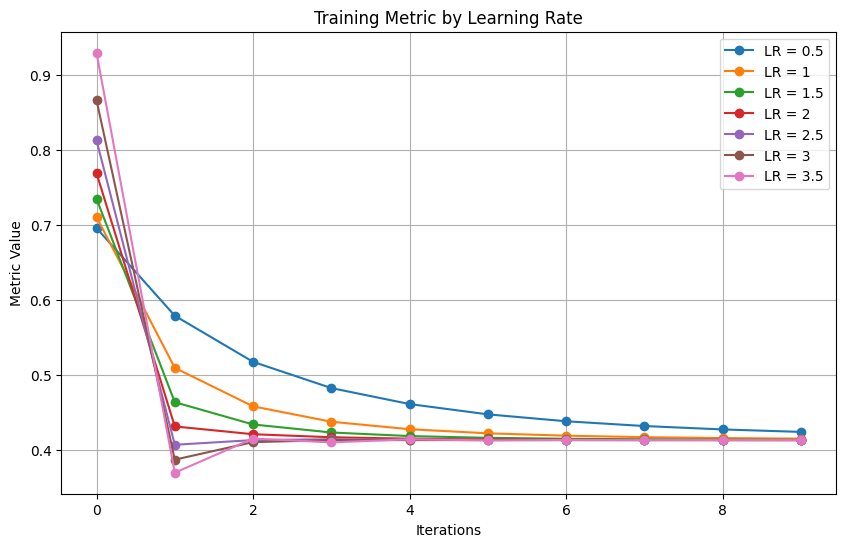

In [19]:
plt.figure(figsize=(10, 6))

for lr, metrics in dict_result.items():
    iterations = list(metrics.keys())
    values = list(metrics.values())
    plt.plot(iterations, values, marker='o', label=f'LR = {lr}')

plt.title('Training Metric by Learning Rate')
plt.xlabel('Iterations')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)

### EJERCICIO 3.1 b

In [20]:
sc.stop()

In [21]:
# standarize
lambda_reg=[1,2,3,4,5] 
dict_result = {}

for i in lambda_reg:
    sc = SparkContext("local[*]", "Ejercicio 3.1 b")
    # read data
    data=readFile("./botnet_tot_syn_l.csv")
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train_dict(data,10,1.5,i)
    dict_iterations, (w,b) = ws
    acc = accuracy(w,b,data)
    dict_result[i] = dict_iterations
    sc.stop()
        
print(dict_result)


Loss en iteracion 0: 0.7203308124815132


Loss en iteracion 1: 0.44691465693479526


Loss en iteracion 2: 0.40810188414561455


Loss en iteracion 3: 0.3929466820096599


Loss en iteracion 4: 0.38564612149043564


...

Loss en iteracion 6: 0.5295634736063668


Loss en iteracion 7: 0.5294989807793975


Loss en iteracion 8: 0.5295149570375983


Loss en iteracion 9: 0.529510468772649


{1: {0: 0.7203308124815132, 1: 0.44691465693479526, 2: 0.40810188414561455, 3: 0.3929466820096599, 4: 0.38564612149043564, 5: 0.3817293684438013, 6: 0.3794759422847844, 7: 0.3781119889249667, 8: 0.3772536798526492, 9: 0.37669685229035044}, 2: {0: 0.7496705622962473, 1: 0.4764493621732083, 2: 0.45462301966878604, 3: 0.4472289000920367, 4: 0.44418229493471245, 5: 0.44278706185200944, 6: 0.4421061935603698, 7: 0.441760407452724, 8: 0.4415800886424477, 9: 0.44148426131380186}, 3: {0: 0.7789153118093959, 1: 0.48978453914046105, 2: 0.48528473532072813, 3: 0.4827816524832978, 4: 0.48174160594801774, 5: 0.4813442008475358, 6: 0.4811925428889664, 7: 0.4811334712452705, 8: 0.4811098152941512, 9: 0.48110002435809485}, 4: {0: 0.8080700016191863, 1: 0.49025423168847954, 2: 0.5116792550420138, 3: 0.5090051989990618, 4: 0.5088730513939234, 5: 0.5087940581179493, 6: 0.508776836447643, 7: 0.5087712723035203, 8: 0.5087693576108959, 9: 0.5087685337872835}, 5: {0: 0.837139572323846, 1: 0.4811701638399356,

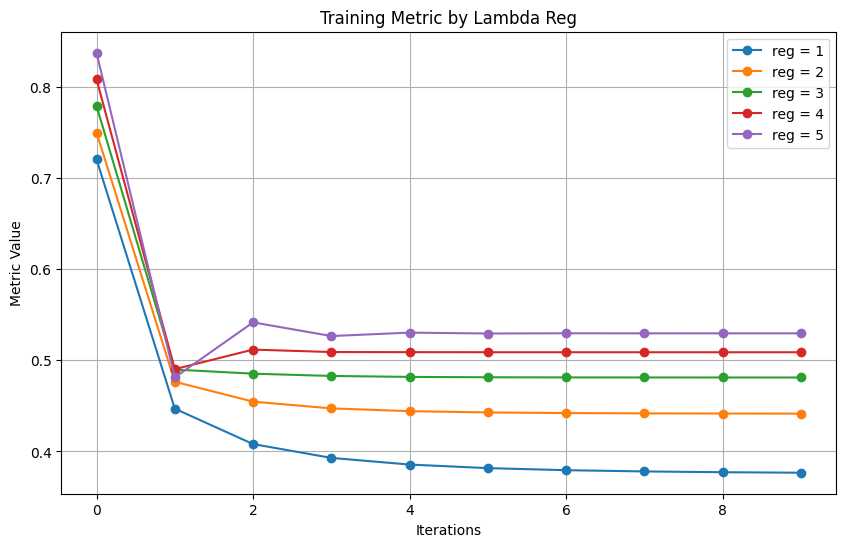

In [22]:
plt.figure(figsize=(10, 6))

for lr, metrics in dict_result.items():
    iterations = list(metrics.keys())
    values = list(metrics.values())
    plt.plot(iterations, values, marker='o', label=f'reg = {lr}')

plt.title('Training Metric by Lambda Reg')
plt.xlabel('Iterations')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)

## EJERCICIO 3.2

In [23]:
sc.stop()

In [24]:
# read data
result = {}
for i in range(1, logical_cores + 3): # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

Experimento con número de workers 1: particiones=1


Loss en iteracion 0: 0.690891121767007


Loss en iteracion 1: 0.39782222304284215


Loss en iteracion 2: 0.3286594783757808


Loss en iteracion 3: 0.2929002608142005


...

Loss en iteracion 0: 0.6908911217669603


Loss en iteracion 1: 0.39782222304366616
Loss en iteracion 2: 0.3286594783761987
Loss en iteracion 3: 0.29290026081443066
Loss en iteracion 4: 0.2701184234229151
Loss en iteracion 5: 0.25404882733445205
Loss en iteracion 6: 0.24199661404222395
Loss en iteracion 7: 0.23257497505045321
Loss en iteracion 8: 0.22498472951149
Loss en iteracion 9: 0.21872780203513598
acc: 0.92944
Experimento con número de workers 16: particiones=16


Loss en iteracion 0: 0.6908911217669595


Loss en iteracion 1: 0.39782222304368253
Loss en iteracion 2: 0.3286594783762076
Loss en iteracion 3: 0.29290026081443515
Loss en iteracion 4: 0.27011842342291825
Loss en iteracion 5: 0.25404882733445433
Loss en iteracion 6: 0.2419966140422251


Loss en iteracion 7: 0.23257497505045402
Loss en iteracion 8: 0.2249847295114902
Loss en iteracion 9: 0.21872780203513623
acc: 0.92944
{1: 43.98640393699998, 2: 23.637358886000015, 3: 16.67630700699999, 4: 12.658247673000005, 5: 10.321479795999949, 6: 8.983653378999975, 7: 8.326437004000013, 8: 7.4430596280000145, 9: 7.064140628999894, 10: 7.017646711999987, 11: 6.947424754000053, 12: 6.701790253000013, 13: 6.526908503000072, 14: 6.582199628999888, 15: 7.453695336999999, 16: 7.657999210999947}


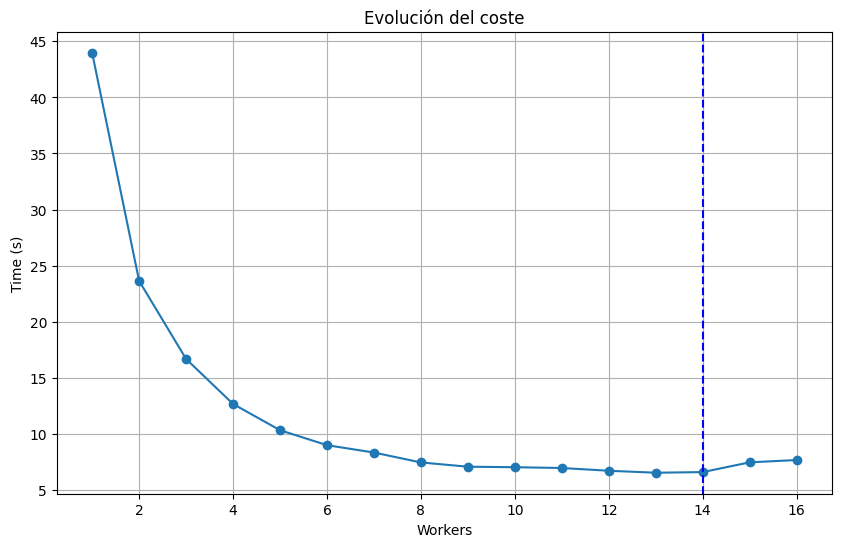

In [25]:
plt.figure(figsize=(10, 6))

xs = sorted(result.keys())
ys = [result[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

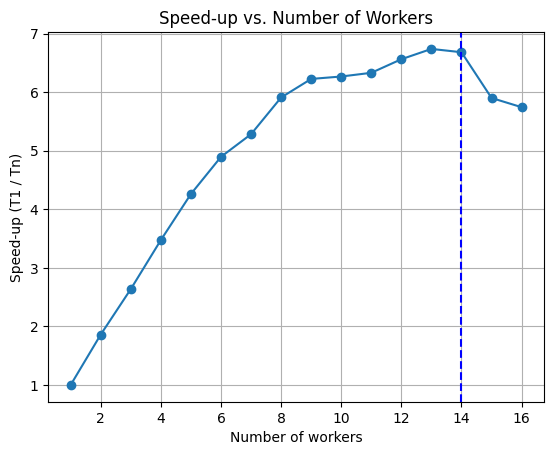

In [26]:
workers = sorted(result.keys())
t1 = result[1]  # baseline

speedup = {w: t1 / result[w] for w in workers}

# plot
plt.plot(workers, [speedup[w] for w in workers], marker="o")
plt.xlabel("Number of workers")
plt.ylabel("Speed-up (T1 / Tn)")
plt.title("Speed-up vs. Number of Workers")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

### EJECUCIÓN CON NORMALIZE_NUMPY

In [28]:
# read data
result32 = {}
for i in range(1, logical_cores + 3): # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    # standarize
    data = normalize_numpy(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result32[i] = time
    sc.stop()
print(result32)

Experimento con número de workers 1: particiones=1


Loss en iteracion 0: 0.690891121767007


Loss en iteracion 1: 0.39782222304284215


Loss en iteracion 2: 0.3286594783757808


Loss en iteracion 3: 0.2929002608142005


...

Loss en iteracion 0: 0.6908911217669617
Loss en iteracion 1: 0.39782222304370873
Loss en iteracion 2: 0.32865947837621867
Loss en iteracion 3: 0.2929002608144423
Loss en iteracion 4: 0.270118423422923
Loss en iteracion 5: 0.2540488273344573
Loss en iteracion 6: 0.24199661404222514
Loss en iteracion 7: 0.2325749750504553
Loss en iteracion 8: 0.224984729511492
Loss en iteracion 9: 0.21872780203513614
acc: 0.92944
Experimento con número de workers 13: particiones=13


Loss en iteracion 0: 0.6908911217669622
Loss en iteracion 1: 0.3978222230436929
Loss en iteracion 2: 0.3286594783762119
Loss en iteracion 3: 0.2929002608144383
Loss en iteracion 4: 0.2701184234229206
Loss en iteracion 5: 0.2540488273344569
Loss en iteracion 6: 0.24199661404222564
Loss en iteracion 7: 0.2325749750504556
Loss en iteracion 8: 0.22498472951149176
Loss en iteracion 9: 0.2187278020351367
acc: 0.92944
Experimento con número de workers 14: particiones=14


Loss en iteracion 0: 0.6908911217669613
Loss en iteracion 1: 0.3978222230436783
Loss en iteracion 2: 0.3286594783762048
Loss en iteracion 3: 0.29290026081443493
Loss en iteracion 4: 0.27011842342291853
Loss en iteracion 5: 0.25404882733445455
Loss en iteracion 6: 0.24199661404222575
Loss en iteracion 7: 0.2325749750504553
Loss en iteracion 8: 0.2249847295114915
Loss en iteracion 9: 0.21872780203513711
acc: 0.92944
Experimento con número de workers 15: particiones=15


Loss en iteracion 0: 0.6908911217669603
Loss en iteracion 1: 0.39782222304366616
Loss en iteracion 2: 0.3286594783761987
Loss en iteracion 3: 0.29290026081443066
Loss en iteracion 4: 0.2701184234229151
Loss en iteracion 5: 0.25404882733445205
Loss en iteracion 6: 0.24199661404222395
Loss en iteracion 7: 0.23257497505045321
Loss en iteracion 8: 0.22498472951149
Loss en iteracion 9: 0.21872780203513598
acc: 0.92944
Experimento con número de workers 16: particiones=16


Loss en iteracion 0: 0.6908911217669595
Loss en iteracion 1: 0.39782222304368253
Loss en iteracion 2: 0.3286594783762076
Loss en iteracion 3: 0.29290026081443515
Loss en iteracion 4: 0.27011842342291825
Loss en iteracion 5: 0.25404882733445433
Loss en iteracion 6: 0.2419966140422251
Loss en iteracion 7: 0.23257497505045402
Loss en iteracion 8: 0.2249847295114902
Loss en iteracion 9: 0.21872780203513623
acc: 0.92944
{1: 39.02793360099997, 2: 20.41751855099983, 3: 13.819725672999994, 4: 11.183280838999963, 5: 9.175549586999978, 6: 7.940741420999984, 7: 7.1386212949998935, 8: 6.506844335999858, 9: 6.061604043999978, 10: 6.43205141999988, 11: 6.060282002999884, 12: 6.222982128000012, 13: 6.197187377000091, 14: 6.238320169999952, 15: 6.652736961000073, 16: 6.326952169999913}


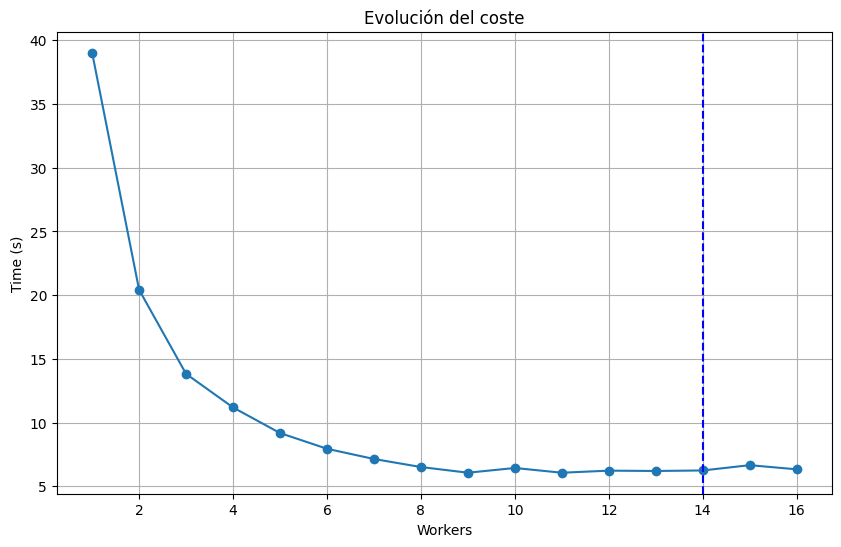

In [29]:
plt.figure(figsize=(10, 6))

xs = sorted(result32.keys())
ys = [result32[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

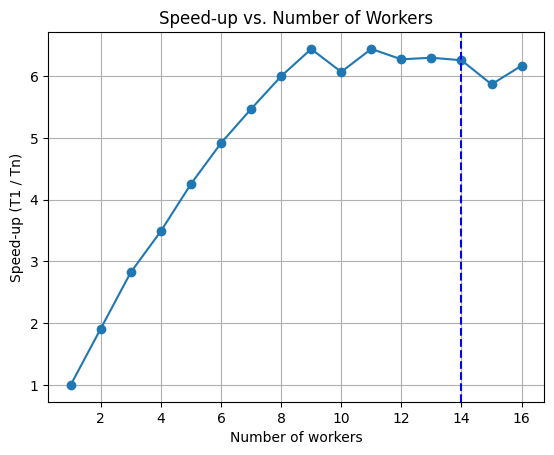

In [30]:
workers = sorted(result32.keys())
t1 = result32[1]  # baseline

speedup = {w: t1 / result32[w] for w in workers}

# plot
plt.plot(workers, [speedup[w] for w in workers], marker="o")
plt.xlabel("Number of workers")
plt.ylabel("Speed-up (T1 / Tn)")
plt.title("Speed-up vs. Number of Workers")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

In [51]:
sc.stop()

## EJERCICIO 3.3

#### DAG

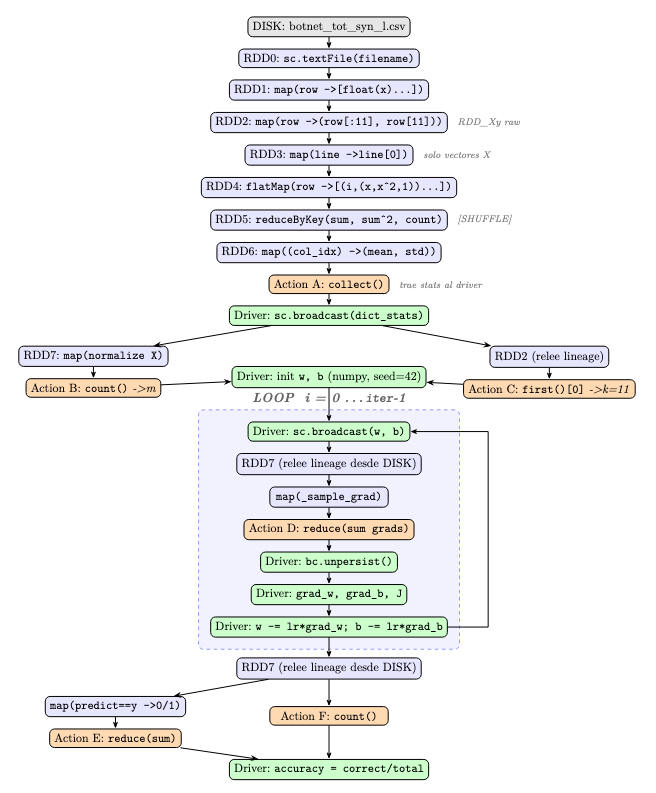

### FUNCIONES DE ENTRENAMIENTO EN DIFERENTES UBICACIONES DE CACHÉ

In [17]:
def accuracy_cache (w, b, RDD_Xy, i): 
    '''Arguments: 
    w -- weights 
    b -- bias 
    RDD_Xy – RDD containing examples to be predicted  
    Returns: 
    accuracy -- the number of predictions that are correct divided by the number         
    of records (examples) in RDD_xy.  
    Predict function can be used for predicting a single example'''
    pred_ok = RDD_Xy.map(
            lambda xy: 1 if predict(w, b, xy[0]) == int(xy[1]) else 0
        )
    if(i==3 or i==5):
        pred_ok.cache()
    correct = pred_ok.reduce(lambda a, c: a + c)
    total = RDD_Xy.count()
    return correct / total if total > 0 else 0.0

In [18]:
def train_cache(RDD_Xy, iterations, learning_rate, lambda_reg, i):
    '''Arguments: 
    RDD_Xy --- RDD containing data examples. Each record of the RDD is a tuple 
    (X,y). 
    “X” is an array containing the 11 features (float number) of an example 
    “y” is the label of the example (integer 0/1)  
    iterations -- number of iterations of the optimization loop 
    learning_rate -- learning rate of the gradient descent 
    lambda_reg – regularization rate: l2 es el que vamos a aplicar
    
    Returns: 
    A list or array containing the weights “w” and bias “b”	at the end of the 
    training process'''	

    sc = RDD_Xy.context
    #data = RDD_Xy.cache()
    data = RDD_Xy

    m = data.count()
    if m == 0:
        raise ValueError("RDD_Xy vacío")

    k = len(data.first()[0])  # 11
    cost=[]
    # inicialización
    rng = np.random.default_rng(42)
    w = rng.normal(0, 0.01, size=k).astype(np.float64)
    b = float(rng.normal(0, 0.01))
    for i in range(iterations):
        bc_w = sc.broadcast(w)
        bc_b = sc.broadcast(b)

        # suma de gradientes por todo el dataset
        rdd_map = data.map(
            lambda xy: _sample_grad(xy, bc_w.value, bc_b.value)
        )
        if(i==2 or i==4 or i==5):
            rdd_map = rdd_map.cache()
        sum_grad_w, sum_grad_b, sum_loss = rdd_map.reduce(
            lambda a, c: (a[0] + c[0],a[1] + c[1], a[2] + c[2])
        )

        bc_w.unpersist()
        bc_b.unpersist()

        # promedio + L2
        grad_w = (sum_grad_w / m) + (lambda_reg / k) * w   # si tu rúbrica usa /k
        grad_b = (sum_grad_b / m)
        
        # update
        w = w - learning_rate * grad_w
        b = b - learning_rate * grad_b
        reg_term = (lambda_reg / (2*k)) * float(np.dot(w,w))
        J = (sum_loss / m ) + reg_term
        #cost[i]=J
        print(f"Loss en iteracion {i}: {J}")
    data.unpersist()
    return [w, b]

#### EJECUCION ORIGINAL

In [ ]:
import matplotlib.pyplot as plt

labels = list(results.keys())
times = list(results.values())

plt.figure()

bars = plt.bar(labels, times)

plt.xlabel("Cache Mode")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time by Cache Strategy")

plt.xticks(rotation=45)
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [ ]:
results

In [ ]:
# read data
sc.stop()
result = {}
for i in range(1, 14 + 3): 
    # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    data.cache()
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

In [ ]:
sc.stop()

In [ ]:
# read data
result2 = {}
for i in range(1, 14 + 3): 
    # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    data.cache()
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result2[i] = time
    sc.stop()
print(result)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ordenamos workers
xs1 = sorted(result.keys())
ys1 = [result[x] for x in xs1]

xs2 = sorted(result2.keys())
ys2 = [result2[x] for x in xs2]

plt.plot(xs1, ys1, marker='o')
plt.plot(xs2, ys2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Execution Time Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment No Cache", "Experiment Cache"])
plt.show()

In [ ]:
workers1 = sorted(result.keys())
workers2 = sorted(result2.keys())

t1_res1 = result[1]
t1_res2 = result2[1]

speedup1 = [t1_res1 / result[w] for w in workers1]
speedup2 = [t1_res2 / result2[w] for w in workers2]

plt.figure(figsize=(10, 6))

plt.plot(workers1, speedup1, marker='o')
plt.plot(workers2, speedup2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Speed-up (T1 / Tn)")
plt.title("Speed-up Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment No Cache", "Experiment Cache"])
plt.show()

#### EJECUCION ORDENADOR PEDRO

In [23]:
sc.stop()

In [32]:
logical_cores = os.cpu_count()
print(f"Logical cores: {logical_cores}")

Logical cores: 8


In [24]:
cache_modes = ["cache_at_source", "cache_at_normalize", "cache_at_train", "cache_at_accuracy","cache_path1", "cache_path2", "no_cache"]
results = {}
for i in range(0,7):
    print(f"FASE {i}")
    sc = SparkContext(f"local[8]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(14)
    if(i==0):
        data.cache()
    data = normalize_numpy(data)
    if(i==1 or i==4):
        data.cache()    
    ws = train_cache(data,10,1.5,0.0,i)
    w,b = ws
    acc = accuracy_cache(w,b,data,i)
    time = perf_counter() - t0
    results[cache_modes[i]] = time
    print("acc:",acc)
    sc.stop()


FASE 0


26/03/15 12:02:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

Loss en iteracion 0: 0.6908911217669613


Loss en iteracion 1: 0.3978222230436783


Loss en iteracion 2: 0.3286594783762048


...

Loss en iteracion 6: 0.24199661404222575


Loss en iteracion 7: 0.2325749750504553


Loss en iteracion 8: 0.2249847295114915


Loss en iteracion 9: 0.21872780203513711


acc: 0.92944


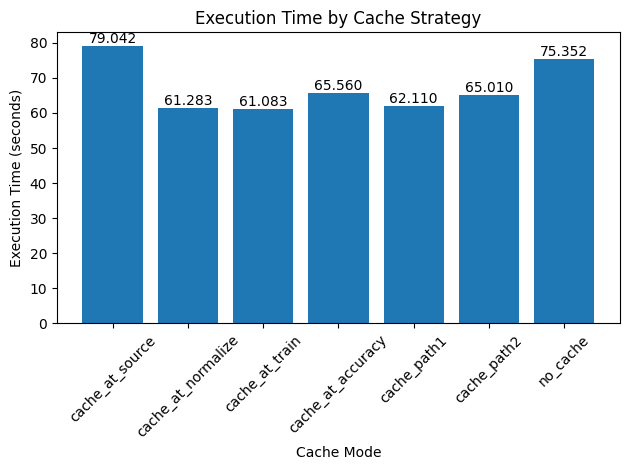

In [25]:
import matplotlib.pyplot as plt

labels = list(results.keys())
times = list(results.values())

plt.figure()

bars = plt.bar(labels, times)

plt.xlabel("Cache Mode")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time by Cache Strategy")

plt.xticks(rotation=45)
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

In [26]:
results

{'cache_at_source': 79.04226659599999,
 'cache_at_normalize': 61.28291393199993,
 'cache_at_train': 61.08283780800002,
 'cache_at_accuracy': 65.55995350299997,
 'cache_path1': 62.10988573299994,
 'cache_path2': 65.00974581499997,
 'no_cache': 75.35150538300002}

In [28]:
# read data
sc.stop()
result = {}
for i in range(1, 14 + 3): 
    # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    data.cache()
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

26/03/15 12:12:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Experimento con número de workers 1: particiones=1


26/03/15 12:13:12 WARN BlockManager: Task 12 already completed, not releasing lock for rdd_6_0
                                                                                

Loss en iteracion 0: 0.690891121767007


Loss en iteracion 1: 0.39782222304284215


...

Loss en iteracion 6: 0.2419966140422251


Loss en iteracion 7: 0.23257497505045402


Loss en iteracion 8: 0.2249847295114902


Loss en iteracion 9: 0.21872780203513623


acc: 0.92944
{1: 106.33906893100016, 2: 71.71737090500005, 3: 62.984668951, 4: 62.159451178999916, 5: 63.32932410700005, 6: 56.80133637900008, 7: 62.807622279999805, 8: 65.40812372100004, 9: 78.69508667200012, 10: 66.19562303600014, 11: 65.21785199099986, 12: 67.05392484899994, 13: 73.328435378, 14: 68.19761770800005, 15: 74.39299613100002, 16: 71.80000528999972}


In [29]:
sc.stop()

In [35]:
# read data
result2 = {}
for i in range(1, 14 + 3): 
    # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    #data.cache()
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train_cache(data,10,1.5,0.0, 2)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result2[i] = time
    sc.stop()
print(result)

26/03/15 12:59:50 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Experimento con número de workers 1: particiones=1


Loss en iteracion 0: 0.690891121767007


Loss en iteracion 1: 0.39782222304284215


Loss en iteracion 2: 0.3286594783757808


...

Loss en iteracion 6: 0.2419966140422251


Loss en iteracion 7: 0.23257497505045402


Loss en iteracion 8: 0.2249847295114902


Loss en iteracion 9: 0.21872780203513623


acc: 0.92944
{1: 106.33906893100016, 2: 71.71737090500005, 3: 62.984668951, 4: 62.159451178999916, 5: 63.32932410700005, 6: 56.80133637900008, 7: 62.807622279999805, 8: 65.40812372100004, 9: 78.69508667200012, 10: 66.19562303600014, 11: 65.21785199099986, 12: 67.05392484899994, 13: 73.328435378, 14: 68.19761770800005, 15: 74.39299613100002, 16: 71.80000528999972}


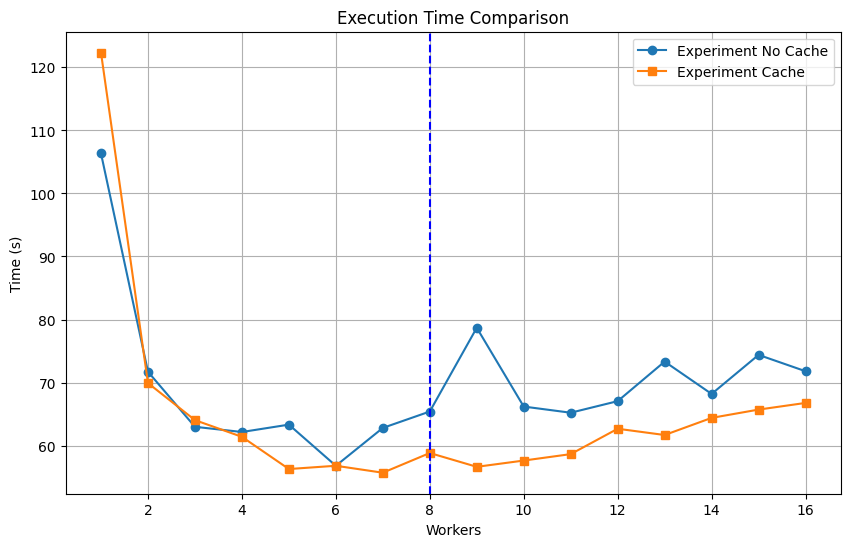

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ordenamos workers
xs1 = sorted(result.keys())
ys1 = [result[x] for x in xs1]

xs2 = sorted(result2.keys())
ys2 = [result2[x] for x in xs2]

plt.plot(xs1, ys1, marker='o')
plt.plot(xs2, ys2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Execution Time Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment No Cache", "Experiment Cache"])
plt.show()

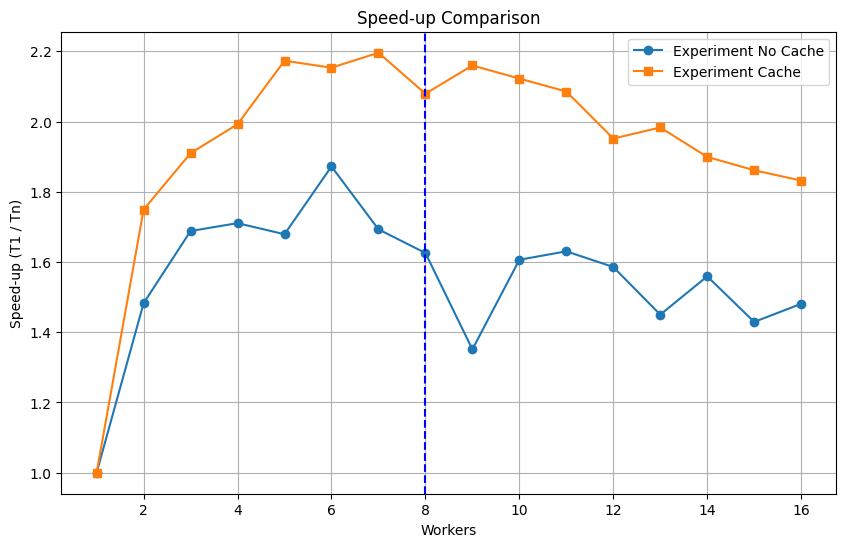

In [37]:
workers1 = sorted(result.keys())
workers2 = sorted(result2.keys())

t1_res1 = result[1]
t1_res2 = result2[1]

speedup1 = [t1_res1 / result[w] for w in workers1]
speedup2 = [t1_res2 / result2[w] for w in workers2]

plt.figure(figsize=(10, 6))

plt.plot(workers1, speedup1, marker='o')
plt.plot(workers2, speedup2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Speed-up (T1 / Tn)")
plt.title("Speed-up Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment No Cache", "Experiment Cache"])
plt.show()

In [20]:
sc.stop()

### Estrategias de Caché en el Pipeline PySpark

| Estrategia | Punto de cache | Observación |
|---|---|---|
| **cache_at_source** | Tras `readFile`, antes de normalizar | El shuffle de normalización se recalcula igualmente |
| **cache_at_normalize** | Tras `normalize_numpy` (RDD7) | Mayor reutilización teórica: evita releer lineage completo en todo el pipeline |
| **cache_at_train** | `rdd_map` dentro del loop | Inútil: cada iteración genera un `rdd_map` distinto que nunca se reutiliza |
| **cache_at_accuracy** | `pred_ok` en `accuracy()` | Evita releer `RDD_Xy` dos veces durante la evaluación |
| **cache_path1** | Normalize + interno del loop | El cache del loop sigue siendo redundante |
| **cache_path2** | Normalize + loop + accuracy | Mayor overhead acumulado del experimento |
| **no_cache** | Sin cache | Óptimo empírico para datasets pequeños en local |
| **cache_optimal** | Solo RDD7 + `unpersist()` al final | Óptimo teórico para datasets grandes en entornos distribuidos con I/O de red |

In [42]:
def train_cache(RDD_Xy, iterations, learning_rate, lambda_reg, mode):
    """
    mode controla dónde se aplica cache dentro del loop:
      2 -> cache rdd_map en iteraciones pares
      5 -> cache rdd_map en iteraciones pares (parte de path2)
      7 -> sin cache interno (óptimo: el cache ya está en data)
    """
    sc   = RDD_Xy.context
    data = RDD_Xy
    m    = data.count()
    if m == 0:
        raise ValueError("RDD_Xy vacío")
    k = len(data.first()[0])

    rng = np.random.default_rng(42)
    w   = rng.normal(0, 0.01, size=k).astype(np.float64)
    b   = float(rng.normal(0, 0.01))

    for i in range(iterations):
        bc_w    = sc.broadcast(w)
        bc_b    = sc.broadcast(b)
        rdd_map = data.map(lambda xy: _sample_grad(xy, bc_w.value, bc_b.value))

        if mode in (2, 5) and (i % 2 == 0):
            rdd_map = rdd_map.cache()

        sum_grad_w, sum_grad_b, sum_loss = rdd_map.reduce(
            lambda a, c: (a[0] + c[0], a[1] + c[1], a[2] + c[2])
        )
        bc_w.unpersist()
        bc_b.unpersist()

        grad_w = (sum_grad_w / m) + (lambda_reg / k) * w
        grad_b =  sum_grad_b / m
        w      = w - learning_rate * grad_w
        b      = b - learning_rate * grad_b

        reg_term = (lambda_reg / (2 * k)) * float(np.dot(w, w))
        J        = (sum_loss / m) + reg_term
        print(f"  iter {i:2d}  loss={J:.6f}")

    return [w, b]


def accuracy_cache(w, b, RDD_Xy, mode):
    pred_ok = RDD_Xy.map(lambda xy: 1 if predict(w, b, xy[0]) == int(xy[1]) else 0)

    if mode in (3, 5):
        pred_ok = pred_ok.cache()

    correct = pred_ok.reduce(lambda a, c: a + c)
    total   = RDD_Xy.count()
    return correct / total if total > 0 else 0.0


cache_modes = [
    "cache_at_source",     
    "cache_at_normalize",   
    "cache_at_train",       
    "cache_at_accuracy",    
    "cache_path1",          # 4 — cache tras normalizar + cache rdd_map
    "cache_path2",          # 5 — cache tras normalizar + cache rdd_map + cache pred_ok
    "no_cache",            
    "cache_optimal",       
]

results = {}

for mode in range(len(cache_modes)):
    print(f"\n{'='*40}")
    print(f"MODO {mode}: {cache_modes[mode]}")
    print(f"{'='*40}")

    sc   = SparkContext("local[8]", f"Prueba_{mode}")
    t0   = perf_counter()

    data = readFile("./botnet_tot_syn_l.csv").repartition(14)

    if mode == 0:
        data = data.cache()                 

    data = normalize_numpy(data)

    if mode in (1, 4, 5, 7):
        data = data.cache()                  

    w, b = train_cache(data, 10, 1.5, 0.0, mode)
    acc  = accuracy_cache(w, b, data, mode)

    data.unpersist()                         

    elapsed              = perf_counter() - t0
    results[cache_modes[mode]] = elapsed

    print(f"  accuracy : {acc:.4f}")
    print(f"  tiempo   : {elapsed:.3f}s")

    sc.stop()

# Resumen
print(f"\n{'='*40}")
print("RESUMEN")
print(f"{'='*40}")
best = min(results, key=results.get)
for name, t in results.items():
    marker = " <-- MEJOR" if name == best else ""
    print(f"  {name:<25} {t:.3f}s{marker}")


MODO 0: cache_at_source


26/03/10 15:37:52 WARN BlockManager: Task 51 already completed, not releasing lock for rdd_6_0


  iter  0  loss=0.690891
  iter  1  loss=0.397822
  iter  2  loss=0.328659
  iter  3  loss=0.292900
  iter  4  loss=0.270118
  iter  5  loss=0.254049
  iter  6  loss=0.241997
  iter  7  loss=0.232575
  iter  8  loss=0.224985
  iter  9  loss=0.218728
  accuracy : 0.9294
  tiempo   : 7.557s

MODO 1: cache_at_normalize


26/03/10 15:38:01 WARN BlockManager: Task 51 already completed, not releasing lock for rdd_9_0


  iter  0  loss=0.690891
  iter  1  loss=0.397822
  iter  2  loss=0.328659
  iter  3  loss=0.292900
  iter  4  loss=0.270118
  iter  5  loss=0.254049
  iter  6  loss=0.241997
  iter  7  loss=0.232575
  iter  8  loss=0.224985
  iter  9  loss=0.218728
  accuracy : 0.9294
  tiempo   : 7.397s

MODO 2: cache_at_train


...

  iter  5  loss=0.254049


  iter  6  loss=0.241997


  iter  7  loss=0.232575
  iter  8  loss=0.224985
  iter  9  loss=0.218728
  accuracy : 0.9294
  tiempo   : 7.915s

MODO 7: cache_optimal


26/03/10 15:38:59 WARN BlockManager: Task 51 already completed, not releasing lock for rdd_9_0


  iter  0  loss=0.690891
  iter  1  loss=0.397822
  iter  2  loss=0.328659
  iter  3  loss=0.292900
  iter  4  loss=0.270118
  iter  5  loss=0.254049
  iter  6  loss=0.241997
  iter  7  loss=0.232575
  iter  8  loss=0.224985
  iter  9  loss=0.218728
  accuracy : 0.9294
  tiempo   : 7.572s

RESUMEN
  cache_at_source           7.557s
  cache_at_normalize        7.397s <-- MEJOR
  cache_at_train            10.461s
  cache_at_accuracy         7.751s
  cache_path1               7.512s
  cache_path2               10.323s
  no_cache                  7.915s
  cache_optimal             7.572s


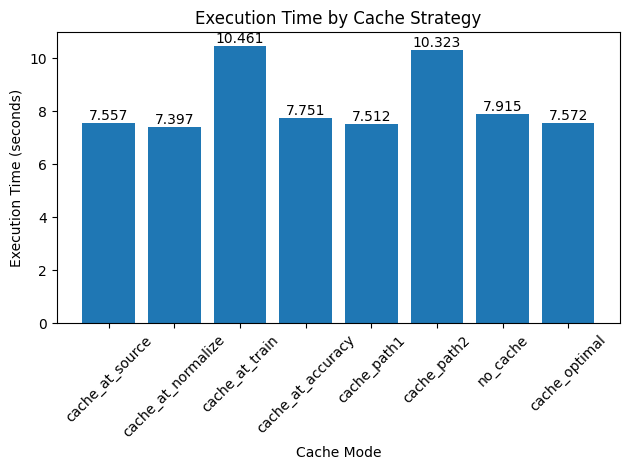

In [43]:
import matplotlib.pyplot as plt

labels = list(results.keys())
times = list(results.values())

plt.figure()

bars = plt.bar(labels, times)

plt.xlabel("Cache Mode")
plt.ylabel("Execution Time (seconds)")
plt.title("Execution Time by Cache Strategy")

plt.xticks(rotation=45)
plt.tight_layout()

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom'
    )

plt.show()

Para este dataset concreto el óptimo empírico es no aplicar cache, ya que el fichero CSV es suficientemente pequeño como para que el sistema operativo lo mantenga en su page cache tras la primera lectura, eliminando el coste de I/O en las iteraciones posteriores. En un entorno local[8] sin red, el único overhead que introduce .cache() es la serialización y la gestión de bloques en el BlockManager de Spark, que con solo 10 iteraciones nunca llega a amortizarse. El cache es fundamentalmente una optimización de I/O, y cuando ese I/O ya está resuelto por el SO, añadir cache solo suma latencia — como demuestran cache_at_train y cache_path2, que son los dos peores resultados precisamente porque son los que más caches innecesarios acumulan.


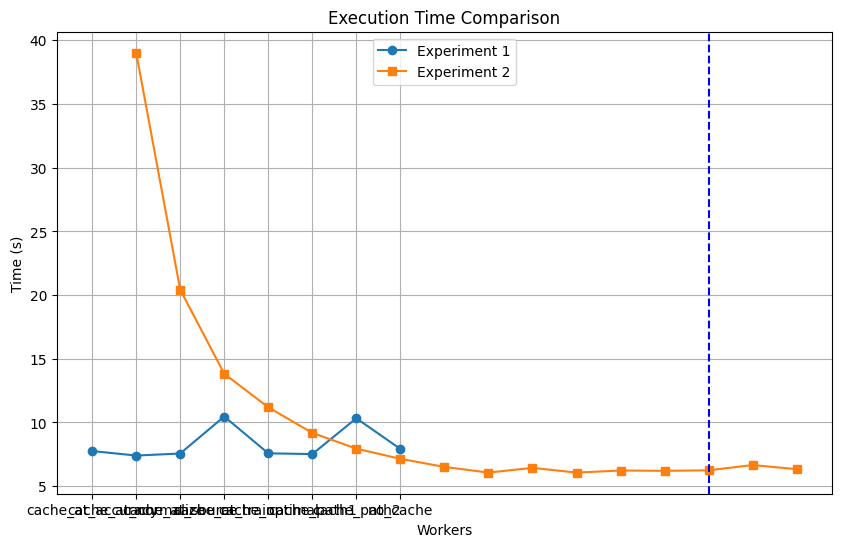

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Ordenamos workers
xs1 = sorted(results.keys())
ys1 = [results[x] for x in xs1]

xs2 = sorted(result32.keys())
ys2 = [result32[x] for x in xs2]

plt.plot(xs1, ys1, marker='o')
plt.plot(xs2, ys2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Execution Time Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment 1", "Experiment 2"])
plt.show()

In [46]:
workers1 = sorted(results.keys())
workers2 = sorted(result32.keys())

t1_res1 = results[1]
t1_res2 = result32[1]

speedup1 = [t1_res1 / results[w] for w in workers1]
speedup2 = [t1_res2 / result32[w] for w in workers2]

plt.figure(figsize=(10, 6))

plt.plot(workers1, speedup1, marker='o')
plt.plot(workers2, speedup2, marker='s')

plt.xlabel("Workers")
plt.ylabel("Speed-up (T1 / Tn)")
plt.title("Speed-up Comparison")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.legend(["Experiment 1", "Experiment 2"])
plt.show()

KeyError: 1

## EJERCICIO 3.4

In [33]:
sc.stop()

In [34]:
# read data
result = {}
for i in range(1, 9):
    sc = SparkContext(f"local[{4}]", f"Prueba_{i}")
    # Ver información del SparkContext
    print(f"Master: {sc.master}")
    print(f"Default parallelism: {sc.defaultParallelism}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    print(f'Experimento con número de workers 4: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

26/03/07 17:30:35 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Master: local[4]
Default parallelism: 4
Experimento con número de workers 4: particiones=1


Loss en iteracion 0: 0.690891121767007


Loss en iteracion 1: 0.39782222304284215


Loss en iteracion 2: 0.3286594783757808


...

Loss en iteracion 5: 0.25404882733444484


Loss en iteracion 6: 0.24199661404221195


Loss en iteracion 7: 0.23257497505044017


Loss en iteracion 8: 0.22498472951147697


Loss en iteracion 9: 0.218727802035122
acc: 0.92944
{1: 41.64364926899907, 2: 22.35487034400103, 3: 16.3038587989995, 4: 12.76028146399949, 5: 18.739584258999457, 6: 16.442965882000863, 7: 14.48721063100129, 8: 12.846886506000374}


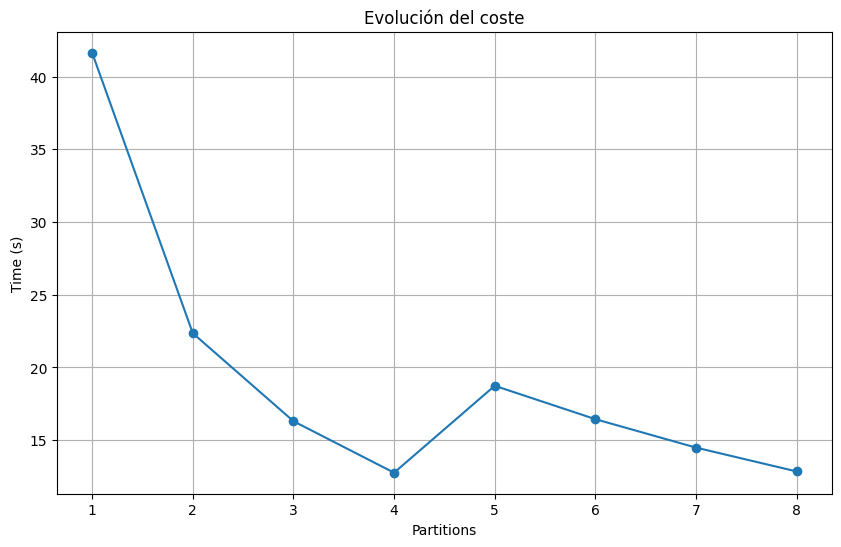

In [35]:
plt.figure(figsize=(10, 6))

xs = sorted(result.keys())
ys = [result[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Partitions")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.show()

### EJECUCIÓN CON NORMALIZE_NUMPY

In [36]:
# read data
result = {}
for i in range(1, 9):
    sc = SparkContext(f"local[{4}]", f"Prueba_{i}")
    # Ver información del SparkContext
    print(f"Master: {sc.master}")
    print(f"Default parallelism: {sc.defaultParallelism}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(i)
    print(f'Experimento con número de workers 4: particiones={data.getNumPartitions()}')
    # standarize
    data = normalize_numpy(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

Master: local[4]
Default parallelism: 4
Experimento con número de workers 4: particiones=1


26/03/07 17:33:19 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
                                                                                

Loss en iteracion 0: 0.690891121771557


Loss en iteracion 1: 0.39782222356676156


Loss en iteracion 2: 0.32865947867676715


...

Loss en iteracion 6: 0.24199661412788798


Loss en iteracion 7: 0.2325749751208068


Loss en iteracion 8: 0.22498472957081314


Loss en iteracion 9: 0.21872780208622813


acc: 0.92944
{1: 57.0964695269995, 2: 30.92647605499951, 3: 21.430890384999657, 4: 16.743307507998907, 5: 25.22929246899912, 6: 21.317266509999172, 7: 19.099185758001113, 8: 17.624130382999283}


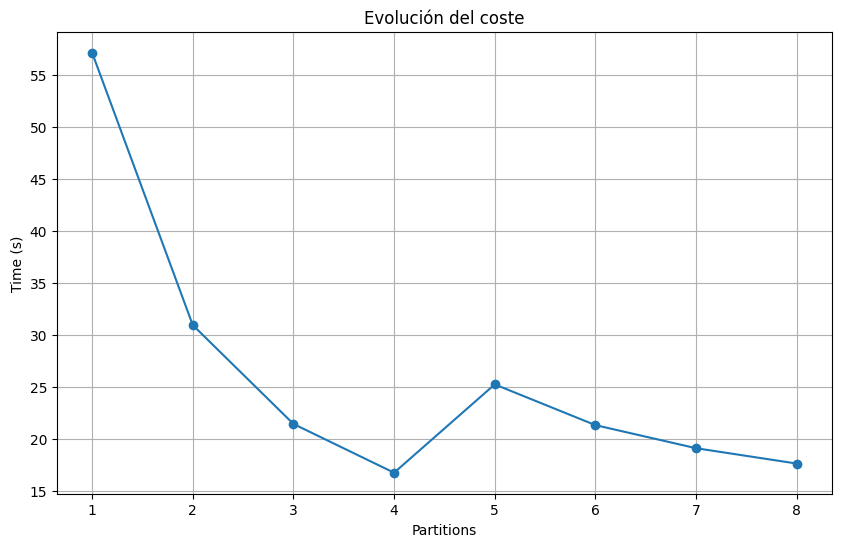

In [37]:
plt.figure(figsize=(10, 6))

xs = sorted(result.keys())
ys = [result[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Partitions")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.show()

## EJERCICIO 3.5

In [48]:
sc.stop()

In [49]:
# read data
result = {}
for i in range(1, logical_cores + 3): # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(2)
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    rows_rdd = data.map(lambda line: line[0])
    cols_rdd = rows_rdd.flatMap(lambda row: [(i, (x,x*x, 1)) for i, x in enumerate(row)])
    group_rdd = cols_rdd.reduceByKey(lambda a,b:(a[0]+b[0],a[1]+b[1],a[2]+b[2]))
    mean_rdd = group_rdd.map(lambda t: (t[0],(t[1][0] / t[1][2], np.sqrt((t[1][1] / t[1][2]) - (t[1][0] / t[1][2])**2))))
    broadcast_var = sc.broadcast(dict(mean_rdd.collect()))
    # standarize
    data = normalize(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

Experimento con número de workers 1: particiones=2


Loss en iteracion 0: 0.6908911217669448


Loss en iteracion 1: 0.39782222304376336


Loss en iteracion 2: 0.32865947837623705


Loss en iteracion 3: 0.29290026081443543


...

Loss en iteracion 6: 0.24199661404220205


Loss en iteracion 7: 0.23257497505043465


Loss en iteracion 8: 0.22498472951147103


Loss en iteracion 9: 0.2187278020351126


acc: 0.92944
{1: 46.142898479999985, 2: 23.598552011000265, 3: 23.82447255199986, 4: 23.119371218000197, 5: 23.456803344000036, 6: 22.844086427999628, 7: 22.988470092999705, 8: 22.232403301999966, 9: 22.190615551000064, 10: 22.5712534270001, 11: 22.523597134999818, 12: 22.344392884999706, 13: 22.798853384999802, 14: 22.863389635999738, 15: 22.742915135999738, 16: 22.59167405199969}


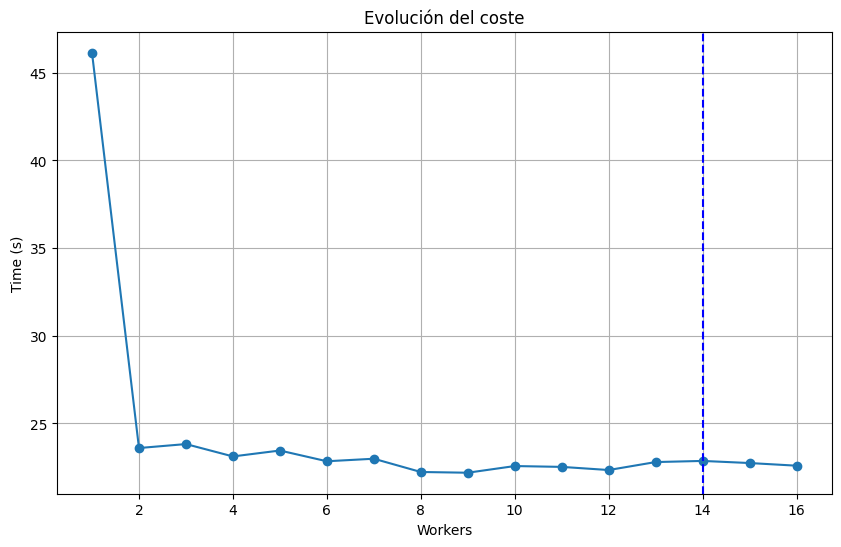

In [50]:
plt.figure(figsize=(10, 6))

xs = sorted(result.keys())
ys = [result[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

### EJECUCIÓN CON NORMALIZE_NUMPY

In [51]:
# read data
result = {}
for i in range(1, logical_cores + 3): # MODIFICAR CUANDO TENGAMOS LA EJECUCION FINAL (CORES + 3)
    sc = SparkContext(f"local[{i}]", f"Prueba_{i}")
    t0 = perf_counter()
    data=readFile("./botnet_tot_syn_l.csv").repartition(2)
    print(f'Experimento con número de workers {i}: particiones={data.getNumPartitions()}')
    # standarize
    data = normalize_numpy(data)
    ws = train(data,10,1.5,0.0)
    w,b = ws
    acc = accuracy(w,b,data)
    print("acc:",acc)
    time = perf_counter() - t0
    result[i] = time
    sc.stop()
print(result)

Experimento con número de workers 1: particiones=2


Loss en iteracion 0: 0.6908911217669448


Loss en iteracion 1: 0.39782222304376336


Loss en iteracion 2: 0.32865947837623705


Loss en iteracion 3: 0.29290026081443543


...

Loss en iteracion 6: 0.24199661404220205


Loss en iteracion 7: 0.23257497505043465


Loss en iteracion 8: 0.22498472951147103


Loss en iteracion 9: 0.2187278020351126


acc: 0.92944
{1: 39.79574964299991, 2: 20.767991302000155, 3: 20.29371042599996, 4: 19.769881174999682, 5: 19.57755000899988, 6: 19.32145988299999, 7: 19.966390884000248, 8: 19.263095258999783, 9: 19.734385799999927, 10: 19.38919234199966, 11: 19.560647218000213, 12: 19.31522546699989, 13: 19.73688634200016, 14: 19.35046850899971, 15: 19.515300426000067, 16: 19.816400508999777}


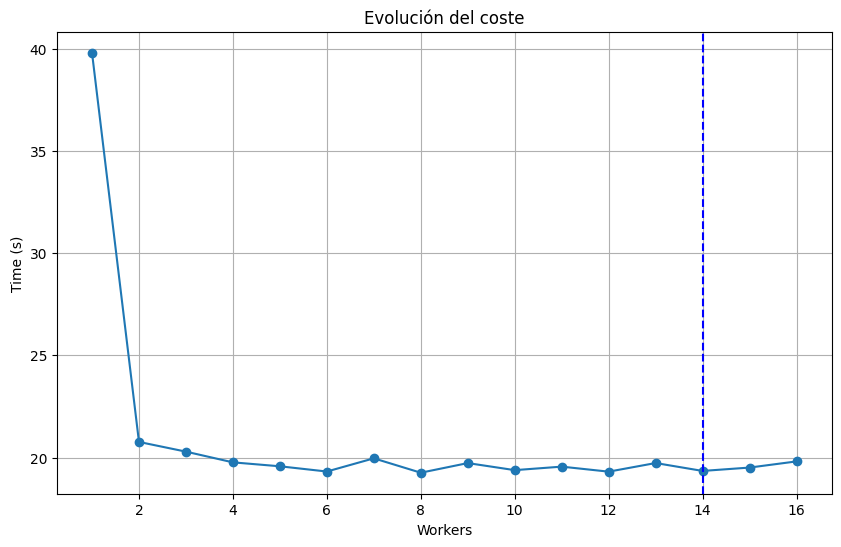

In [52]:
plt.figure(figsize=(10, 6))

xs = sorted(result.keys())
ys = [result[x] for x in xs]

plt.plot(xs, ys, marker='o')   # línea + puntos
plt.xlabel("Workers")
plt.ylabel("Time (s)")
plt.title("Evolución del coste")
plt.grid(True)
plt.axvline(x=logical_cores, color='b', linestyle='--', label=f'Hilos ({logical_cores})')
plt.show()

In [53]:
sc.stop()